In [10]:
# Import necessary functions to fetch Gmail data
from gmail_auth import authenticate_gmail
from fetch_gmail import fetch_recent_emails
from googleapiclient.discovery import build

print("Libraries and functions imported successfully.")

Libraries and functions imported successfully.


Fetch all emails data and create a dictionary with subject, body and labels

In [11]:
def fetch_all_emails_data():
    """
    Fetches all emails including their subject, body (snippet), and labels.
    Handles pagination to retrieve the entire inbox.
    """
    creds = authenticate_gmail()
    service = build("gmail", "v1", credentials=creds)
    
    # 1. Fetch labels to map IDs to readable names
    label_results = service.users().labels().list(userId="me").execute()
    labels = label_results.get("labels", [])
    label_map = {label["id"]: label["name"] for label in labels}

    # 2. Fetch all messages using pagination
    print("Fetching all messages (this might take a while depending on your inbox size)...")
    messages = []
    request = service.users().messages().list(userId="me", maxResults=500)
    
    while request is not None:
        result = request.execute()
        messages.extend(result.get('messages', []))
        print(f"  ... retrieved {len(messages)} message IDs so far")
        request = service.users().messages().list_next(previous_request=request, previous_response=result)

    if not messages:
        print("No messages found.")
        return []

    print(f"Total messages to process: {len(messages)}")
    email_dataset = []

    # 3. Process each message
    for i, msg in enumerate(messages):
        if i > 0 and i % 100 == 0:
            print(f"  ... processed {i}/{len(messages)} messages")
            
        try:
            # format='metadata' with snippet is efficient for getting basic content
            msg_detail = service.users().messages().get(
                userId="me", 
                id=msg["id"], 
                format="metadata", 
                metadataHeaders=["Subject"]
            ).execute()

            # Extract Subject
            headers = msg_detail.get("payload", {}).get("headers", [])
            subject = "(No Subject)"
            for header in headers:
                if header["name"].lower() == "subject":
                    subject = header["value"]
                    break
                    
            # Extract Body (snippet represents the body content)
            body = msg_detail.get("snippet", "")

            # Extract Labels
            label_ids = msg_detail.get("labelIds", [])
            readable_labels = [label_map.get(l_id, l_id) for l_id in label_ids]

            email_dataset.append({
                "subject": subject,
                "body": body,
                "labels": readable_labels
            })
        except Exception as e:
            print(f"Error processing message {msg['id']}: {e}")
            
    print(f"Finished processing {len(email_dataset)} emails!")
    return email_dataset

# Fetch all data
gmail_data = fetch_all_emails_data()

# Print the results to verify
print("\n--- Sample Data Extracted ---\n")
for i, email in enumerate(gmail_data[:5]):
    print(f"Email {i+1}:")
    print(f"  Subject: {email['subject']}")
    print(f"  Labels:  {', '.join(email['labels'])}")
    print(f"  Body:    {email['body']}...\n")

Fetching all messages (this might take a while depending on your inbox size)...
  ... retrieved 500 message IDs so far
  ... retrieved 1000 message IDs so far
  ... retrieved 1500 message IDs so far
  ... retrieved 2000 message IDs so far
  ... retrieved 2500 message IDs so far
  ... retrieved 3000 message IDs so far
  ... retrieved 3500 message IDs so far
  ... retrieved 4000 message IDs so far
  ... retrieved 4500 message IDs so far
  ... retrieved 5000 message IDs so far
  ... retrieved 5500 message IDs so far
  ... retrieved 6000 message IDs so far
  ... retrieved 6500 message IDs so far
  ... retrieved 7000 message IDs so far
  ... retrieved 7500 message IDs so far
  ... retrieved 8000 message IDs so far
  ... retrieved 8500 message IDs so far
  ... retrieved 9000 message IDs so far
  ... retrieved 9500 message IDs so far
  ... retrieved 10000 message IDs so far
  ... retrieved 10500 message IDs so far
  ... retrieved 11000 message IDs so far
  ... retrieved 11500 message IDs so f

In [12]:
import pandas as pd

# Convert list of dictionaries (gmail_data) into a Pandas DataFrame
gmail_data_df = pd.DataFrame(gmail_data)

# Display first few rows of the DataFrame
print(gmail_data_df.head())

# Save to a CSV file
gmail_data_df.to_csv("gmail_emails.csv", index=False)
print("Gmail emails data saved to gmail_emails.csv")


                                             subject  \
0  Employer Posted Machine Learning Engineer Job ...   
1  Agatri Jaya just posted a 98% match Machine Le...   
2     Your job alert for: ML Engineer, Irving, Texas   
3  Your job alert for: Machine Learning Engineer,...   
4     Your job alert for: ML Engineer, United States   

                                                body  \
0  SimVentions, Inc - Glassdoor ✪ 4․6 and Corpora...   
1  Worcester, MA Jobright Instant Alert Always be...   
2  Jobot is hiring. ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌...   
3  Lennar Homes is hiring. ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏...   
4  Jobot is hiring. ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌...   

                              labels  
0  [UNREAD, CATEGORY_UPDATES, INBOX]  
1  [UNREAD, CATEGORY_UPDATES, INBOX]  
2  [UNREAD, CATEGORY_UPDATES, INBOX]  
3  [UNREAD, CATEGORY_UPDATES, INBOX]  
4  [UNREAD, CATEGORY_UPDATES, INBOX]  
Gmail emails data saved to gmail_emails.csv


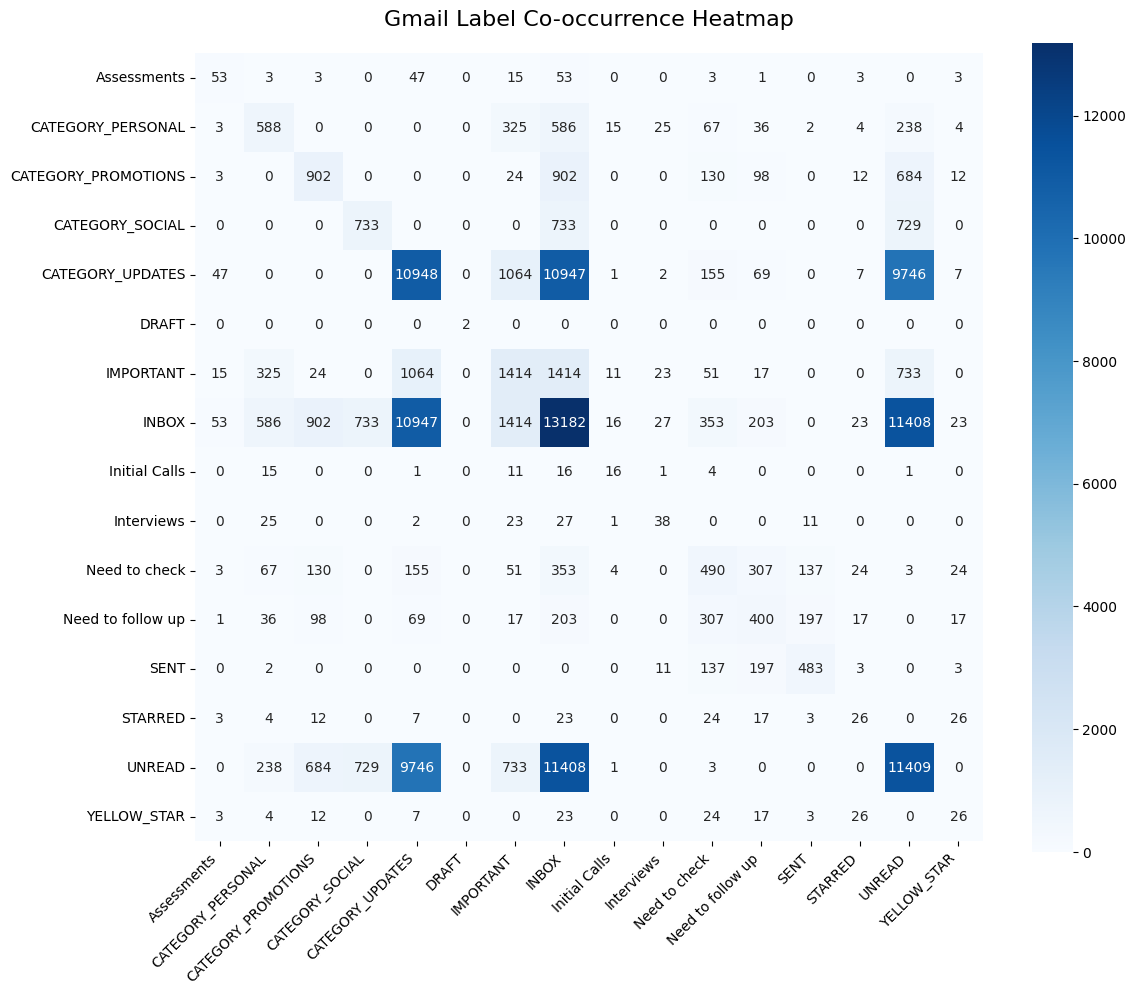

In [13]:
import ast
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load the saved CSV
df = pd.read_csv("gmail_emails.csv")

# Parse string representations of lists into actual Python lists
df["labels_list"] = df["labels"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else []
)

# Identify all unique labels
all_labels = sorted(
    list(set(label for sublist in df["labels_list"] for label in sublist))
)

# Create a binary indicator DataFrame (1 if label present, 0 otherwise)
indicator_df = pd.DataFrame(0, index=df.index, columns=all_labels)
for label in all_labels:
    indicator_df[label] = df["labels_list"].apply(lambda x: 1 if label in x else 0)

# Calculate co-occurrence matrix using matrix multiplication
co_occurrence_matrix = indicator_df.T.dot(indicator_df)

# Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    co_occurrence_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    square=True,
    xticklabels=all_labels,
    yticklabels=all_labels
)
plt.title("Gmail Label Co-occurrence Heatmap", fontsize=16, pad=20)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [14]:
import ast
import pandas as pd

# Load the saved CSV
df = pd.read_csv("gmail_emails.csv")

# Parse string representations of lists into actual Python lists
df["labels_list"] = df["labels"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else []
)

# Define the set of labels to remove (in lowercase for case-insensitive matching)
labels_to_remove = {
    "category_personal",
    "category_promotions",
    "category_social",
    "category_updates",  # Handles "category_ipdates" typo
    "draft",
    "sent",
    "starred",
    "unread",
    "IMPORTANT"
}

# Remove only the specified labels from the lists, keeping the emails
df["labels_list"] = df["labels_list"].apply(
    lambda labels: [lbl for lbl in labels if lbl.lower().strip() not in labels_to_remove]
)

# Convert the lists back to string representation for CSV storage
df["labels"] = df["labels_list"].apply(str)

# Remove the temporary column
df = df.drop(columns=["labels_list"])

df.head()


,subject,body,labels
0,Employer Posted Machine Learning Engineer Job ...,"SimVentions, Inc - Glassdoor ✪ 4․6 and Corpora...",['INBOX']
1,Agatri Jaya just posted a 98% match Machine Le...,"Worcester, MA Jobright Instant Alert Always be...",['INBOX']
2,"Your job alert for: ML Engineer, Irving, Texas",Jobot is hiring. ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌...,['INBOX']
3,"Your job alert for: Machine Learning Engineer,...",Lennar Homes is hiring. ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏...,['INBOX']
4,"Your job alert for: ML Engineer, United States",Jobot is hiring. ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌...,['INBOX']


In [15]:
import ast
import pandas as pd


# Parse string representations of lists into actual Python lists
df["labels_list"] = df["labels"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else []
)

# Flatten the lists of labels and calculate their frequencies
label_counts = pd.Series(
    [label for sublist in df["labels_list"] for label in sublist]
).value_counts()

# Display the unique labels and counts
print("--- Unique Labels and Frequencies ---")
print(label_counts)


--- Unique Labels and Frequencies ---
INBOX                13182
IMPORTANT             1414
Need to check          490
Need to follow up      400
Assessments             53
Interviews              38
YELLOW_STAR             26
Initial Calls           16
Name: count, dtype: int64


In [16]:
import ast
import pandas as pd


# Parse string representations of lists into actual Python lists
df["labels_list"] = df["labels"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else []
)

# Define the labels that indicate an email needs to be checked 
# (using lowercase for case-insensitive matching)
important_labels = {
    "important", 
    "need to check", 
    "need to follow up", 
    "assessments", 
    "interviews", 
    "yellow_star", 
    "initial calls"
}

# Function to determine the new binary label
def categorize_email(labels):
    # Check if any of the email's labels match our important list
    for lbl in labels:
        if lbl.lower().strip() in important_labels:
            return "Need to check"
    
    # If no important labels were found, mark it as ignore
    return "Ignore"

# Apply the categorization and overwrite the 'labels' column
df["labels"] = df["labels_list"].apply(categorize_email)

# Drop the temporary list column
df = df.drop(columns=["labels_list"])

# Save the updated DataFrame back to the CSV file
df.to_csv("gmail_emails.csv", index=False)
print("Successfully converted labels into 'Need to check' and 'Ignore'.")

# Display the distribution of the new labels
print("\n--- New Label Distribution ---")
print(df["labels"].value_counts())


Successfully converted labels into 'Need to check' and 'Ignore'.

--- New Label Distribution ---
labels
Ignore           11669
Need to check     1999
Name: count, dtype: int64
